In [ ]:
# Remove the corrupted file
!rm TCGA-PANCAN-HiSeq-801x20531.tar.gz

# Download the verified dataset from UCI
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00401/TCGA-PANCAN-HiSeq-801x20531.tar.gz

# Extract it properly
!tar -xvzf TCGA-PANCAN-HiSeq-801x20531.tar.gz

rm: cannot remove 'TCGA-PANCAN-HiSeq-801x20531.tar.gz': No such file or directory
--2026-03-16 13:29:25--  https://archive.ics.uci.edu/ml/machine-learning-databases/00401/TCGA-PANCAN-HiSeq-801x20531.tar.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘TCGA-PANCAN-HiSeq-801x20531.tar.gz’

TCGA-PANCAN-HiSeq-8     [         <=>        ]  69.48M  39.9MB/s    in 1.7s    

2026-03-16 13:29:27 (39.9 MB/s) - ‘TCGA-PANCAN-HiSeq-801x20531.tar.gz’ saved [72856320]

TCGA-PANCAN-HiSeq-801x20531/
TCGA-PANCAN-HiSeq-801x20531/data.csv
TCGA-PANCAN-HiSeq-801x20531/labels.csv


In [ ]:
import os
path = "TCGA-PANCAN-HiSeq-801x20531"
print("Files in folder:", os.listdir(path))

Files in folder: ['labels.csv', 'data.csv']


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.multiclass import OneVsRestClassifier

# File paths
data_path = 'TCGA-PANCAN-HiSeq-801x20531/data.csv'
labels_path = 'TCGA-PANCAN-HiSeq-801x20531/labels.csv'

# 1. Load normally without the dtype argument
X = pd.read_csv(data_path, index_col=0)
y = pd.read_csv(labels_path, index_col=0)

# 1b. Now cast to float32 to save 50% RAM (safe because the index is already separated)
X = X.astype(np.float32)

print(f"Loaded {X.shape[0]} samples and {X.shape[1]} genes.")

# Ensure y is a clean 1D array
y_clean = y.values.ravel()

# 2. Log-Transform
X_log = np.log1p(X)

# ... (the rest of your original code continues here exactly as before)
# 3. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_clean,
    test_size=0.2,
    stratify=y_clean,
    random_state=42
)

# 4. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 5. Train the Lasso Model (SPEED HACKS + TRACKER ENABLED)
print("Training the Pan-Cancer Lasso Model. Watch the parallel jobs finish...")

base_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    C=0.005,
    max_iter=1000,
    tol=0.01,
    random_state=42
)

# Add verbose=5
model = OneVsRestClassifier(base_model, n_jobs=-1, verbose=5)

model.fit(X_train_scaled, y_train)

# 6. Results
print("\n--- Model Accuracy ---")
print(classification_report(y_test, model.predict(X_test_scaled)))

# 7. Extract the "Keys" (Gene Signatures)
weights_matrix = np.array([est.coef_[0] for est in model.estimators_])

for i, cancer_type in enumerate(model.classes_):
    active_genes = np.sum(weights_matrix[i] != 0)
    print(f"{cancer_type} Key: {active_genes} active genes identified.")

np.save('sparse_weights.npy', weights_matrix)

Loaded 801 samples and 20531 genes.
Training the Pan-Cancer Lasso Model. Watch the parallel jobs finish...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



--- Model Accuracy ---
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

BRCA Key: 28 active genes identified.
COAD Key: 44 active genes identified.
KIRC Key: 57 active genes identified.
LUAD Key: 23 active genes identified.
PRAD Key: 40 active genes identified.


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.2min finished


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier

# 1. Load Data
data_path = 'TCGA-PANCAN-HiSeq-801x20531/data.csv'
labels_path = 'TCGA-PANCAN-HiSeq-801x20531/labels.csv'

X = pd.read_csv(data_path, index_col=0).astype(np.float32)
y = pd.read_csv(labels_path, index_col=0)
y_clean = y.values.ravel()

# 2. Log transform
X_log = np.log1p(X)

print(f"\nDataset shape: {X_log.shape}")
print("Class distribution:")
print(pd.Series(y_clean).value_counts())

# 3. Create pipeline (Using OneVsRest for speed and warning fix)
base_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    tol=0.01,
    random_state=42
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', OneVsRestClassifier(base_model))
])

# 4. Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 5. Try multiple C values (Focusing on smaller values for a tighter Payload)
C_values = [0.05, 0.01, 0.005]

print("\n--- Cross Validation Results ---")

for C in C_values:
    # Set C inside the OneVsRest wrapper
    pipeline.set_params(model__estimator__C=C)

    print(f"Testing C = {C} (Running 5 folds in parallel...)")
    scores = cross_val_score(
        pipeline,
        X_log,
        y_clean,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1  # Handles the parallel processing for the 5 folds safely
    )

    print(f"Mean CV Accuracy: {scores.mean():.4f} (Std Dev: {scores.std():.4f})")
    print("-" * 40)

# 6. Fit final model with best C
# We will assume 0.005 gives the best balance of accuracy and privacy payload size
best_C = 0.005
pipeline.set_params(model__estimator__C=best_C)
print(f"\nFitting final model with C = {best_C}...")
pipeline.fit(X_log, y_clean)

# 7. Count active genes
# Extracting weights matrix from the wrapper
final_model = pipeline.named_steps['model']
weights_matrix = np.array([est.coef_[0] for est in final_model.estimators_])

print("\n--- Active Genes Per Cancer ---")
for i, cancer_type in enumerate(final_model.classes_):
    active_genes = np.sum(weights_matrix[i] != 0)
    print(f"{cancer_type}: {active_genes} active genes")

np.save('sparse_weights.npy', weights_matrix)


Dataset shape: (801, 20531)
Class distribution:
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64

--- Cross Validation Results ---
Testing C = 0.05 (Running 5 folds in parallel...)
Mean CV Accuracy: 0.9975 (Std Dev: 0.0050)
----------------------------------------
Testing C = 0.01 (Running 5 folds in parallel...)
Mean CV Accuracy: 0.9988 (Std Dev: 0.0025)
----------------------------------------
Testing C = 0.005 (Running 5 folds in parallel...)
Mean CV Accuracy: 1.0000 (Std Dev: 0.0000)
----------------------------------------

Fitting final model with C = 0.005...

--- Active Genes Per Cancer ---
BRCA: 55 active genes
COAD: 56 active genes
KIRC: 73 active genes
LUAD: 36 active genes
PRAD: 49 active genes


In [ ]:
from google.colab import files

# Download the raw payload weights
files.download('sparse_weights.npy')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import joblib
from google.colab import files

# Save the entire trained pipeline (scaler + model)
joblib.dump(pipeline, 'pan_cancer_lasso_model.pkl')

# Download it to your laptop
files.download('pan_cancer_lasso_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
import shutil

# This will ask for permission to connect your Google Drive
drive.mount('/content/drive')

# Copy the files directly into your Drive
shutil.copy('sparse_weights.npy', '/content/drive/MyDrive/sparse_weights.npy')
shutil.copy('pan_cancer_lasso_model.pkl', '/content/drive/MyDrive/pan_cancer_lasso_model.pkl')

print("Safely backed up to Google Drive!")

Mounted at /content/drive
Safely backed up to Google Drive!


In [ ]:
import numpy as np
import pandas as pd

# 1. Load your saved payload and just the column headers from the dataset
weights = np.load('sparse_weights.npy')
genes = pd.read_csv('TCGA-PANCAN-HiSeq-801x20531/data.csv', nrows=0, index_col=0).columns

# The classes your model learned (alphabetical order)
cancer_classes = ['BRCA', 'COAD', 'KIRC', 'LUAD', 'PRAD']

print("--- EXPLAINABLE AI: TOP 5 BIOMARKERS PER CANCER ---")

for i, cancer in enumerate(cancer_classes):
    cancer_weights = weights[i]

    # Find genes that survived the Lasso penalty
    active_indices = np.where(cancer_weights != 0)[0]

    # Sort them by absolute weight (highest importance first)
    sorted_indices = active_indices[np.argsort(-np.abs(cancer_weights[active_indices]))]

    print(f"\n{cancer} Top 5 Genes:")
    for idx in sorted_indices[:5]:
        print(f"  {genes[idx]} (Weight: {cancer_weights[idx]:.4f})")

--- EXPLAINABLE AI: TOP 5 BIOMARKERS PER CANCER ---

BRCA Top 5 Genes:
  gene_7964 (Weight: -0.0669)
  gene_17801 (Weight: -0.0590)
  gene_15589 (Weight: 0.0513)
  gene_6611 (Weight: -0.0376)
  gene_6748 (Weight: -0.0358)

COAD Top 5 Genes:
  gene_14845 (Weight: 0.0404)
  gene_2037 (Weight: 0.0381)
  gene_11652 (Weight: 0.0348)
  gene_5830 (Weight: 0.0276)
  gene_8596 (Weight: -0.0270)

KIRC Top 5 Genes:
  gene_14114 (Weight: 0.0322)
  gene_220 (Weight: 0.0313)
  gene_2288 (Weight: -0.0285)
  gene_16131 (Weight: 0.0282)
  gene_219 (Weight: 0.0280)

LUAD Top 5 Genes:
  gene_15895 (Weight: 0.0626)
  gene_15899 (Weight: 0.0606)
  gene_15898 (Weight: 0.0515)
  gene_15591 (Weight: 0.0499)
  gene_15896 (Weight: 0.0498)

PRAD Top 5 Genes:
  gene_18135 (Weight: 0.0375)
  gene_12881 (Weight: 0.0362)
  gene_12847 (Weight: 0.0361)
  gene_6937 (Weight: 0.0335)
  gene_12848 (Weight: 0.0313)


In [ ]:
import pandas as pd
import numpy as np

# 1. Point this to the file
synapse_file = 'unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv'

print(f"Loading true biological names from {synapse_file}...")
# We only read the very first column so your computer's RAM doesn't crash
real_genes_df = pd.read_csv(synapse_file, sep='\t', usecols=[0])

# Convert that column into a simple list
real_genes_list = real_genes_df.iloc[:, 0].tolist()

# 2. Exact dummy genes from the model output
dummy_genes = [
    'gene_7964', 'gene_17801', 'gene_15589', 'gene_6611', 'gene_6748', # BRCA
    'gene_14845', 'gene_2037', 'gene_11652', 'gene_5830', 'gene_8596'  # COAD
]

print("\n--- Translated Biological Cancer Drivers ---")
for dummy in dummy_genes:
    # Extract the number from 'gene_7964' -> 7964
    index = int(dummy.split('_')[1])

    # Map it to the Synapse list (the true, un-alphabetized source)
    # The split('|')[0] cleans up the Synapse format (e.g., "BRCA1|672" -> "BRCA1")
    raw_name = str(real_genes_list[index])
    clean_name = raw_name.split('|')[0]
    print(f"{dummy}  --->  {clean_name}")

print("\n--- Mathematical Sanity Check (Fingerprinting) ---")
# Verify that gene_7964 is mathematically identical to the translated gene
try:
    uci_data = pd.read_csv('TCGA-PANCAN-HiSeq-801x20531/data.csv', index_col=0)
    dummy_gene_data = uci_data['gene_7964']
    print(f"UCI 'gene_7964'         -> Min: {dummy_gene_data.min():.4f}, Max: {dummy_gene_data.max():.4f}")

    target_gene = real_genes_list[7964]
    with open(synapse_file, 'r') as f:
        for line in f:
            if line.startswith(f'{target_gene}\t'):
                synapse_vals = [float(x) for x in line.strip().split('\t')[1:] if x != 'NA']
                print(f"Synapse '{clean_name}' -> Min: {min(synapse_vals):.4f}, Max: {max(synapse_vals):.4f}")
                print("\nSUCCESS: If the Min/Max match exactly, the translation is mathematically proven!")
                break
except Exception as e:
    print(f"\nSanity check skipped (make sure 'data.csv' is in the folder). Error: {e}")

Loading true biological names from unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv...

--- Translated Biological Cancer Drivers ---
gene_7964  --->  HNF1B
gene_17801  --->  TCF21
gene_15589  --->  SCGB2A2
gene_6611  --->  FOXF1
gene_6748  --->  FZD5
gene_14845  --->  RETNLB
gene_2037  --->  C17orf73
gene_11652  --->  NCRNA00114
gene_5830  --->  FABP2
gene_8596  --->  IRX3

--- Mathematical Sanity Check (Fingerprinting) ---
UCI 'gene_7964'         -> Min: 0.0000, Max: 13.2323
Synapse 'IRX3' -> Min: 0.0000, Max: 18319.9000

SUCCESS: If the Min/Max match exactly, the translation is mathematically proven!


In [ ]:
# 1. Count the genes in the Synapse file
synapse_file = 'unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv'
synapse_df = pd.read_csv(synapse_file, sep='\t', usecols=[0])
print(f"Synapse Gene Count: {len(synapse_df)}")

# 2. Count the genes in the Xena file
xena_file = 'EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
xena_df = pd.read_csv(xena_file, sep='\t', usecols=[0])
print(f"Xena Gene Count: {len(xena_df)}")

Synapse Gene Count: 20531
Xena Gene Count: 20531


In [ ]:
import pandas as pd

# 1. Point to the Synapse file
synapse_file = 'unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv'
print(f"Loading true biological names from {synapse_file}...\n")

# Read only the first column to save RAM
real_genes_df = pd.read_csv(synapse_file, sep='\t', usecols=[0])
real_genes_list = real_genes_df.iloc[:, 0].tolist()

# 2. The exact weights from your Phase 1 output
cancer_signatures = {
    "BRCA (Breast)": ['gene_7964', 'gene_17801', 'gene_15589', 'gene_6611', 'gene_6748'],
    "COAD (Colon)":  ['gene_14845', 'gene_2037', 'gene_11652', 'gene_5830', 'gene_8596'],
    "KIRC (Kidney)": ['gene_14114', 'gene_220', 'gene_2288', 'gene_16131', 'gene_219'],
    "LUAD (Lung)":   ['gene_15895', 'gene_15899', 'gene_15898', 'gene_15591', 'gene_15896'],
    "PRAD (Prostate)": ['gene_18135', 'gene_12881', 'gene_12847', 'gene_6937', 'gene_12848']
}

# 3. Translate and Print
print("--- TRANSLATED BIOMARKER PAYLOADS ---")
for cancer, genes in cancer_signatures.items():
    print(f"\n{cancer} Top 5 Drivers:")
    for dummy in genes:
        # Extract the index (e.g., 'gene_7964' -> 7964)
        index = int(dummy.split('_')[1])

        # Look up the true name and clean the string (e.g., "BRCA1|672" -> "BRCA1")
        raw_name = str(real_genes_list[index])
        clean_name = raw_name.split('|')[0]

        print(f"  {dummy}  --->  {clean_name}")

Loading true biological names from unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv...

--- TRANSLATED BIOMARKER PAYLOADS ---

BRCA (Breast) Top 5 Drivers:
  gene_7964  --->  HNF1B
  gene_17801  --->  TCF21
  gene_15589  --->  SCGB2A2
  gene_6611  --->  FOXF1
  gene_6748  --->  FZD5

COAD (Colon) Top 5 Drivers:
  gene_14845  --->  RETNLB
  gene_2037  --->  C17orf73
  gene_11652  --->  NCRNA00114
  gene_5830  --->  FABP2
  gene_8596  --->  IRX3

KIRC (Kidney) Top 5 Drivers:
  gene_14114  --->  PRODH2
  gene_220  --->  ACSM2B
  gene_2288  --->  C20orf151
  gene_16131  --->  SLC17A2
  gene_219  --->  ACSM2A

LUAD (Lung) Top 5 Drivers:
  gene_15895  --->  SFTA3
  gene_15899  --->  SFTPC
  gene_15898  --->  SFTPB
  gene_15591  --->  SCGB3A2
  gene_15896  --->  SFTPA1

PRAD (Prostate) Top 5 Drivers:
  gene_18135  --->  TMEFF2
  gene_12881  --->  PAGE4
  gene_12847  --->  PABPC1L2A
  gene_6937  --->  GDEP
  gene_12848  --->  PABPC1L2B


In [ ]:
import pandas as pd
import csv

# 1. Point to the giant Synapse file one last time
synapse_file = 'unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv'

print(f"Extracting all 20,531 gene names from {synapse_file}...")
real_genes_df = pd.read_csv(synapse_file, sep='\t', usecols=[0])
real_genes_list = real_genes_df.iloc[:, 0].tolist()

# 2. Create the permanent dictionary mapping
translation_dict = {}
for i, raw_name in enumerate(real_genes_list):
    # Clean up the Synapse format (e.g., "BRCA1|672" -> "BRCA1")
    clean_name = str(raw_name).split('|')[0]

    # Map 'gene_X' to the clean biological name
    translation_dict[f'gene_{i}'] = clean_name

# 3. Save it as a permanent, lightweight CSV
output_file = 'gene_mapping_dictionary.csv'
with open(output_file, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Dummy_Name', 'Biological_Name'])
    for dummy, real in translation_dict.items():
        writer.writerow([dummy, real])

print(f"Success! Saved permanent translation file to: {output_file}")

Extracting all 20,531 gene names from unc.edu_PANCAN_IlluminaHiSeq_RNASeqV2.geneExp.tsv...
Success! Saved permanent translation file to: gene_mapping_dictionary.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report

# 1. Mount your Google Drive (A popup will ask for permission)
drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/Datasets/'

# Put the exact file names your friend used here:
data_file = 'data.csv'   # Or 'HiSeqV2.csv', etc.
labels_file = 'labels.csv' # Or 'PANCAN_clinicalMatrix.csv', etc.

print("\nLoading massive dataset from Drive... (Might take a minute)")
# astype(np.float32) is your RAM armor
X_raw = pd.read_csv(folder_path + data_file, index_col=0).astype(np.float32)
labels_raw = pd.read_csv(folder_path + labels_file, index_col=0)

# 2. The Universal "Sideways" Fix
# Raw biological datasets usually have Genes as Rows. We need Genes as Columns.
if X_raw.shape[0] > X_raw.shape[1]:
    print("Detected sideways biological data. Transposing matrix...")
    X = X_raw.T
else:
    X = X_raw

# Make sure the labels align perfectly with the matrix
dataset = X.merge(labels_raw, left_index=True, right_index=True)

# Separate back into X and y
X_clean = dataset.iloc[:, :-1]  # All columns except the last one
y_clean = dataset.iloc[:, -1].values.ravel() # The very last column (cancer names)

print(f"\nFinal Dataset shape ready for ML: {X_clean.shape}")

# 3. Log-Transform (Skip if the data is already logged, but safe to run)
X_log = np.log1p(X_clean)

# 4. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_clean, test_size=0.2, stratify=y_clean, random_state=42
)

# 5. Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Train the Model (WITH PROGRESS BAR)
print("\nTraining the model... Watch the parallel jobs finish below:")
base_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    C=0.005,         # Keeping the strict penalty for a small, tight payload
    max_iter=1000,
    tol=0.01,
    random_state=42
)

# verbose=5 is your progress tracker so you don't lose your crap lol
model = OneVsRestClassifier(base_model, n_jobs=-1, verbose=5)
model.fit(X_train_scaled, y_train)

# 7. Verify Results
print("\n--- Model Accuracy ---")
print(classification_report(y_test, model.predict(X_test_scaled)))

# 8. Extract the Payload
weights_matrix = np.array([est.coef_[0] for est in model.estimators_])
for i, cancer_type in enumerate(model.classes_):
    active_genes = np.sum(weights_matrix[i] != 0)
    print(f"{cancer_type}: {active_genes} active genes")

# Save directly back to your Colab environment
np.save('original_dataset_weights.npy', weights_matrix)
print("\nSaved 'original_dataset_weights.npy'!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading massive dataset from Drive... (Might take a minute)

Final Dataset shape ready for ML: (801, 20531)

Training the model... Watch the parallel jobs finish below:


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



--- Model Accuracy ---
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161

BRCA: 28 active genes
COAD: 44 active genes
KIRC: 57 active genes
LUAD: 23 active genes
PRAD: 40 active genes

Saved 'original_dataset_weights.npy'!


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  2.0min finished


In [ ]:
from sklearn.metrics import classification_report

print("--- FINAL MODEL ACCURACY ---")
# Predict on the 20% of data we held back for testing
y_pred = model.predict(X_test_scaled)

# Print the full accuracy report
print(classification_report(y_test, y_pred))

--- FINAL MODEL ACCURACY ---
              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      1.00      1.00        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           1.00       161
   macro avg       1.00      1.00      1.00       161
weighted avg       1.00      1.00      1.00       161



In [ ]:
import shutil

# The path to your Drive folder
folder_path = '/content/drive/MyDrive/Datasets/'

# Copy the file from Colab's temporary memory to your Google Drive
shutil.copy('final_verified_weights.npy', folder_path + 'final_verified_weights.npy')

print("Successfully moved the payload to your Google Drive Datasets folder!")

Successfully moved the payload to your Google Drive Datasets folder!


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import gc # Garbage collector to save RAM

# 1. Mount Drive for the massive data file
drive.mount('/content/drive')
folder_path = '/content/drive/MyDrive/Datasets/'


data_file = 'EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
labels_file = 'PANCAN_clinicalmatrix.tsv'

print("Loading the massive 1.5GB dataset... (Go grab a coffee)")

# Load the heavy data from Drive
X_raw = pd.read_csv(folder_path + data_file, sep='\t', index_col=0).astype(np.float32)

# Load the labels from Colab's local uploaded files!
labels_raw = pd.read_csv('/content/' + labels_file, sep='\t', index_col=0)

# 2. Transpose
print("Transposing matrix...")
X = X_raw.T

# AGGRESSIVE RAM SAVING: Delete the raw matrix immediately
del X_raw
gc.collect()

# 3. Clean Labels and Merge
# Pulling the 'cancer type abbreviation' column
labels_clean = labels_raw[['cancer type abbreviation']].rename(columns={'cancer type abbreviation': 'cancer_type'})

# Merge the biological data with the answer key based on the sample IDs
dataset = X.merge(labels_clean, left_index=True, right_index=True)

# Drop any patients that don't have a cancer label
dataset = dataset.dropna(subset=['cancer_type'])

# Separate back into X and y
X_clean = dataset.drop(columns=['cancer_type'])
y_clean = dataset['cancer_type'].values.ravel()

# Fill all missing doctor data with 0
X_clean.fillna(0, inplace=True)

print(f"\nMaster Dataset shape ready for ML: {X_clean.shape}")

# AGGRESSIVE RAM SAVING: Delete the merged dataset
del dataset, X
gc.collect()

# 4. Stratified Split & Scale
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, stratify=y_clean, random_state=42
)

print("Scaling data...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train the Model
print("\nTraining Lasso on all 33 cancers...")
base_model = LogisticRegression(
    penalty='l1', solver='saga', class_weight='balanced',
    C=0.005, max_iter=1000, tol=0.01, random_state=42
)

# n_jobs=2 prevents the RAM from overflowing while training 33 models
model = OneVsRestClassifier(base_model, n_jobs=2, verbose=5)
model.fit(X_train_scaled, y_train)

# 6. Print Biological Names
weights_matrix = np.array([est.coef_[0] for est in model.estimators_])
real_genes_list = X_clean.columns

print("\n--- THE COMPLETE BIOMARKER LIST FOR ALL 33 CANCERS ---")
for i, cancer in enumerate(model.classes_):
    cancer_weights = weights_matrix[i]
    active_indices = np.where(cancer_weights != 0)[0]
    sorted_indices = active_indices[np.argsort(-np.abs(cancer_weights[active_indices]))]

    print(f"\n========================================")
    print(f"{cancer} - Total Active Drivers: {len(sorted_indices)}")
    print(f"========================================")

    for idx in sorted_indices:
        print(f"  {real_genes_list[idx]} (Weight: {cancer_weights[idx]:.4f})")

# Save straight back to your drive!
np.save(folder_path + 'master_33_cancer_weights.npy', weights_matrix)
print("\nSaved 'master_33_cancer_weights.npy' to your Drive Datasets folder!")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading the massive 1.5GB dataset... (Go grab a coffee)
Transposing matrix...

Master Dataset shape ready for ML: (11014, 20531)
Scaling data...

Training Lasso on ALL 33 CANCERS... This will take a while!


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed: 72.2min
[Parallel(n_jobs=2)]: Done  33 out of  33 | elapsed: 168.4min finished



--- THE COMPLETE BIOMARKER LIST FOR ALL 33 CANCERS ---

ACC - Total Active Drivers: 139
  CYP11B1 (Weight: 0.1760)
  CYP11B2 (Weight: 0.0763)
  MC2R (Weight: 0.0719)
  STAR (Weight: 0.0583)
  CYB5B (Weight: 0.0462)
  NR5A1 (Weight: 0.0414)
  AMHR2 (Weight: 0.0384)
  CLEC4GP1 (Weight: 0.0365)
  GSTA3 (Weight: 0.0352)
  HCRTR2 (Weight: 0.0341)
  CDH1 (Weight: -0.0313)
  CYP17A1 (Weight: 0.0275)
  CLRN1 (Weight: 0.0247)
  SULT2A1 (Weight: 0.0243)
  PLXNB1 (Weight: -0.0226)
  SNORA25 (Weight: 0.0219)
  HS2ST1 (Weight: 0.0202)
  AGRP (Weight: 0.0163)
  XKR3 (Weight: 0.0160)
  KANK1 (Weight: -0.0159)
  ING2 (Weight: 0.0139)
  HSD3B2 (Weight: 0.0135)
  TTTY3B (Weight: 0.0129)
  MYBPC3 (Weight: 0.0129)
  GPLD1 (Weight: -0.0123)
  OR5K4 (Weight: 0.0113)
  ZNF275 (Weight: 0.0111)
  RNASE11 (Weight: 0.0110)
  ERBB3 (Weight: -0.0103)
  MAP3K15 (Weight: 0.0103)
  MAMSTR (Weight: 0.0099)
  SLC24A6 (Weight: 0.0094)
  MPL (Weight: -0.0090)
  MT2A (Weight: 0.0085)
  TOMM34 (Weight: 0.0083)
  RAB11FIP4

In [ ]:
# 7. Save the model & scaler
import joblib
joblib.dump(model, folder_path + 'master_33_cancer_model.pkl')
joblib.dump(scaler, folder_path + 'master_33_cancer_scaler.pkl')
print("✅ Master Model and Scaler safely locked in your Google Drive!")

✅ Master Model and Scaler safely locked in your Google Drive!


In [ ]:
import os
print("Files currently in Colab's memory:")
print(os.listdir('/content/'))

Files currently in Colab's memory:
['.config', 'drive', 'PANCAN_clinicalmatrix.tsv', '.tsv', '.ipynb_checkpoints', 'sample_data']


In [ ]:
import pandas as pd

labels_raw = pd.read_csv('/content/PANCAN_clinicalmatrix.tsv', sep='\t', nrows=5)

print("Here are the exact column names in your file:")
print(labels_raw.columns.tolist())

Here are the exact column names in your file:
['sample', '_PATIENT', 'cancer type abbreviation', 'age_at_initial_pathologic_diagnosis', 'gender', 'race', 'ajcc_pathologic_tumor_stage', 'clinical_stage', 'histological_type', 'histological_grade', 'initial_pathologic_dx_year', 'menopause_status', 'birth_days_to', 'vital_status', 'tumor_status', 'last_contact_days_to', 'death_days_to', 'cause_of_death', 'new_tumor_event_type', 'new_tumor_event_site', 'new_tumor_event_site_other', 'new_tumor_event_dx_days_to', 'treatment_outcome_first_course', 'margin_status', 'residual_tumor', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time', 'Redaction']


In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
import joblib
import gc

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Dataset path
folder_path = '/content/drive/MyDrive/capstone papers/Datasets/'

print("\n1. Loading Master Model & Scaler...")
model = joblib.load(folder_path + 'master_33_cancer_model.pkl')
scaler = joblib.load(folder_path + 'master_33_cancer_scaler.pkl')

print("2. Re-loading the dataset to recreate the test set...")
# Load Expression
X_raw = pd.read_csv(folder_path + 'EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena', sep='\t', index_col=0).astype(np.float32)
X = X_raw.T
del X_raw
gc.collect()

# Load Labels (Pointing to the one saved in your Drive!)
labels_raw = pd.read_csv(folder_path + 'clinical_labels.tsv', sep='\t', index_col=0)
labels_clean = labels_raw[['cancer type abbreviation']].rename(columns={'cancer type abbreviation': 'cancer_type'})

# Merge and Clean
dataset = X.merge(labels_clean, left_index=True, right_index=True).dropna(subset=['cancer_type'])
X_clean = dataset.drop(columns=['cancer_type']).fillna(0)
y_clean = dataset['cancer_type'].values.ravel()
del dataset, X, labels_raw, labels_clean
gc.collect()

# Split to get the EXACT SAME test set
_, X_test, _, y_test = train_test_split(X_clean, y_clean, test_size=0.2, stratify=y_clean, random_state=42)
del X_clean
gc.collect()

print("3. Scaling test data...")
X_test_scaled = scaler.transform(X_test)

print("4. Predicting and Printing Clean Results...\n")
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"OVERALL PAN-CANCER ACCURACY: {acc * 100:.2f}%\n")
print("Detailed Breakdown per Cancer Type:")
print(classification_report(y_test, y_pred))

Mounted at /content/drive

1. Loading Master Model & Scaler...
2. Re-loading the dataset to recreate the test set...
3. Scaling test data...
4. Predicting and Printing Clean Results...

OVERALL PAN-CANCER ACCURACY: 93.55%

Detailed Breakdown per Cancer Type:
              precision    recall  f1-score   support

         ACC       0.89      1.00      0.94        16
        BLCA       0.96      0.94      0.95        85
        BRCA       1.00      0.98      0.99       243
        CESC       0.95      0.90      0.93        62
        CHOL       0.50      0.22      0.31         9
        COAD       0.75      0.98      0.85        98
        DLBC       0.83      1.00      0.91        10
        ESCA       0.86      0.64      0.74        39
         GBM       1.00      0.97      0.98        33
        HNSC       0.99      0.99      0.99       113
        KICH       0.53      0.94      0.68        18
        KIRC       0.97      0.89      0.93       121
        KIRP       0.95      0.85     

In [3]:
import numpy as np
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

folder_path = '/content/drive/MyDrive/capstone papers/Datasets/'

weights = np.array([est.coef_[0] for est in model.estimators_])
classes = model.classes_

print("Extracting 20,531 Gene Names...")
# Read the first COLUMN (usecols=[0]) instead of the first row
xena_expr_file = folder_path + 'EB++AdjustPANCAN_IlluminaHiSeq_RNASeqV2.geneExp.xena'
gene_names = pd.read_csv(xena_expr_file, sep='\t', usecols=[0]).iloc[:, 0].values

# Build a clean DataFrame for the top 5 genes of each cancer
summary_data = []

for i, cancer in enumerate(classes):
    cancer_weights = weights[i]
    active_indices = np.where(cancer_weights != 0)[0]

    # Sort by absolute magnitude to get the strongest positive and negative drivers
    sorted_indices = active_indices[np.argsort(-np.abs(cancer_weights[active_indices]))]

    top_5_genes = gene_names[sorted_indices[:5]].tolist()
    top_5_weights = cancer_weights[sorted_indices[:5]]

    # Formatted : GENE (Weight)
    formatted_top_5 = [f"{gene} ({w:.4f})" for gene, w in zip(top_5_genes, top_5_weights)]
    summary_data.append([cancer] + formatted_top_5)

# Final Presentation Table
columns = ['Cancer Type', 'Top Driver 1', 'Top Driver 2', 'Top Driver 3', 'Top Driver 4', 'Top Driver 5']
df_presentation = pd.DataFrame(summary_data, columns=columns)
df_presentation.set_index('Cancer Type', inplace=True)

print("\n--- 33-CANCER BIOMARKER DISCOVERY ENGINE ---")
display(df_presentation)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting 20,531 Gene Names...

--- 33-CANCER BIOMARKER DISCOVERY ENGINE ---


,Top Driver 1,Top Driver 2,Top Driver 3,Top Driver 4,Top Driver 5
Cancer Type,,,,,
ACC,CYP11B1 (0.1760),CYP11B2 (0.0763),MC2R (0.0719),STAR (0.0583),CYB5B (0.0462)
BLCA,UPK2 (0.0938),LOC284379 (0.0791),UPK1A (0.0640),GPR78 (0.0608),PLA2G2F (0.0582)
BRCA,SCGB2A2 (0.1246),ANKRD30A (0.1061),MAGEB4 (0.0847),TRPS1 (0.0782),C8orf85 (0.0752)
CESC,ARHGEF33 (0.0835),C9orf53 (0.0785),SERPINB4 (0.0666),SERPINB3 (0.0554),C1orf14 (0.0507)
CHOL,CRP (0.0926),ONECUT1 (0.0859),SFRP5 (0.0690),SDC4P (0.0669),APCS (0.0609)
COAD,FAM55A (0.0899),NOX1 (0.0822),RETNLB (0.0603),ZNF512B (-0.0546),FAM55D (0.0527)
DLBC,C7orf72 (0.1691),SAMD7 (0.0831),GTSF1L (0.0474),C12orf77 (0.0468),PLEKHA5 (-0.0423)
ESCA,DSPP (0.0973),BLID (-0.0712),TCEB3C (-0.0676),GAGE12J (0.0653),RPPH1 (0.0625)
GBM,LOC643387 (-0.1110),FTHL3 (-0.1027),NACAP1 (-0.0894),EEF1A1P9 (-0.0819),LOC442454 (-0.0735)


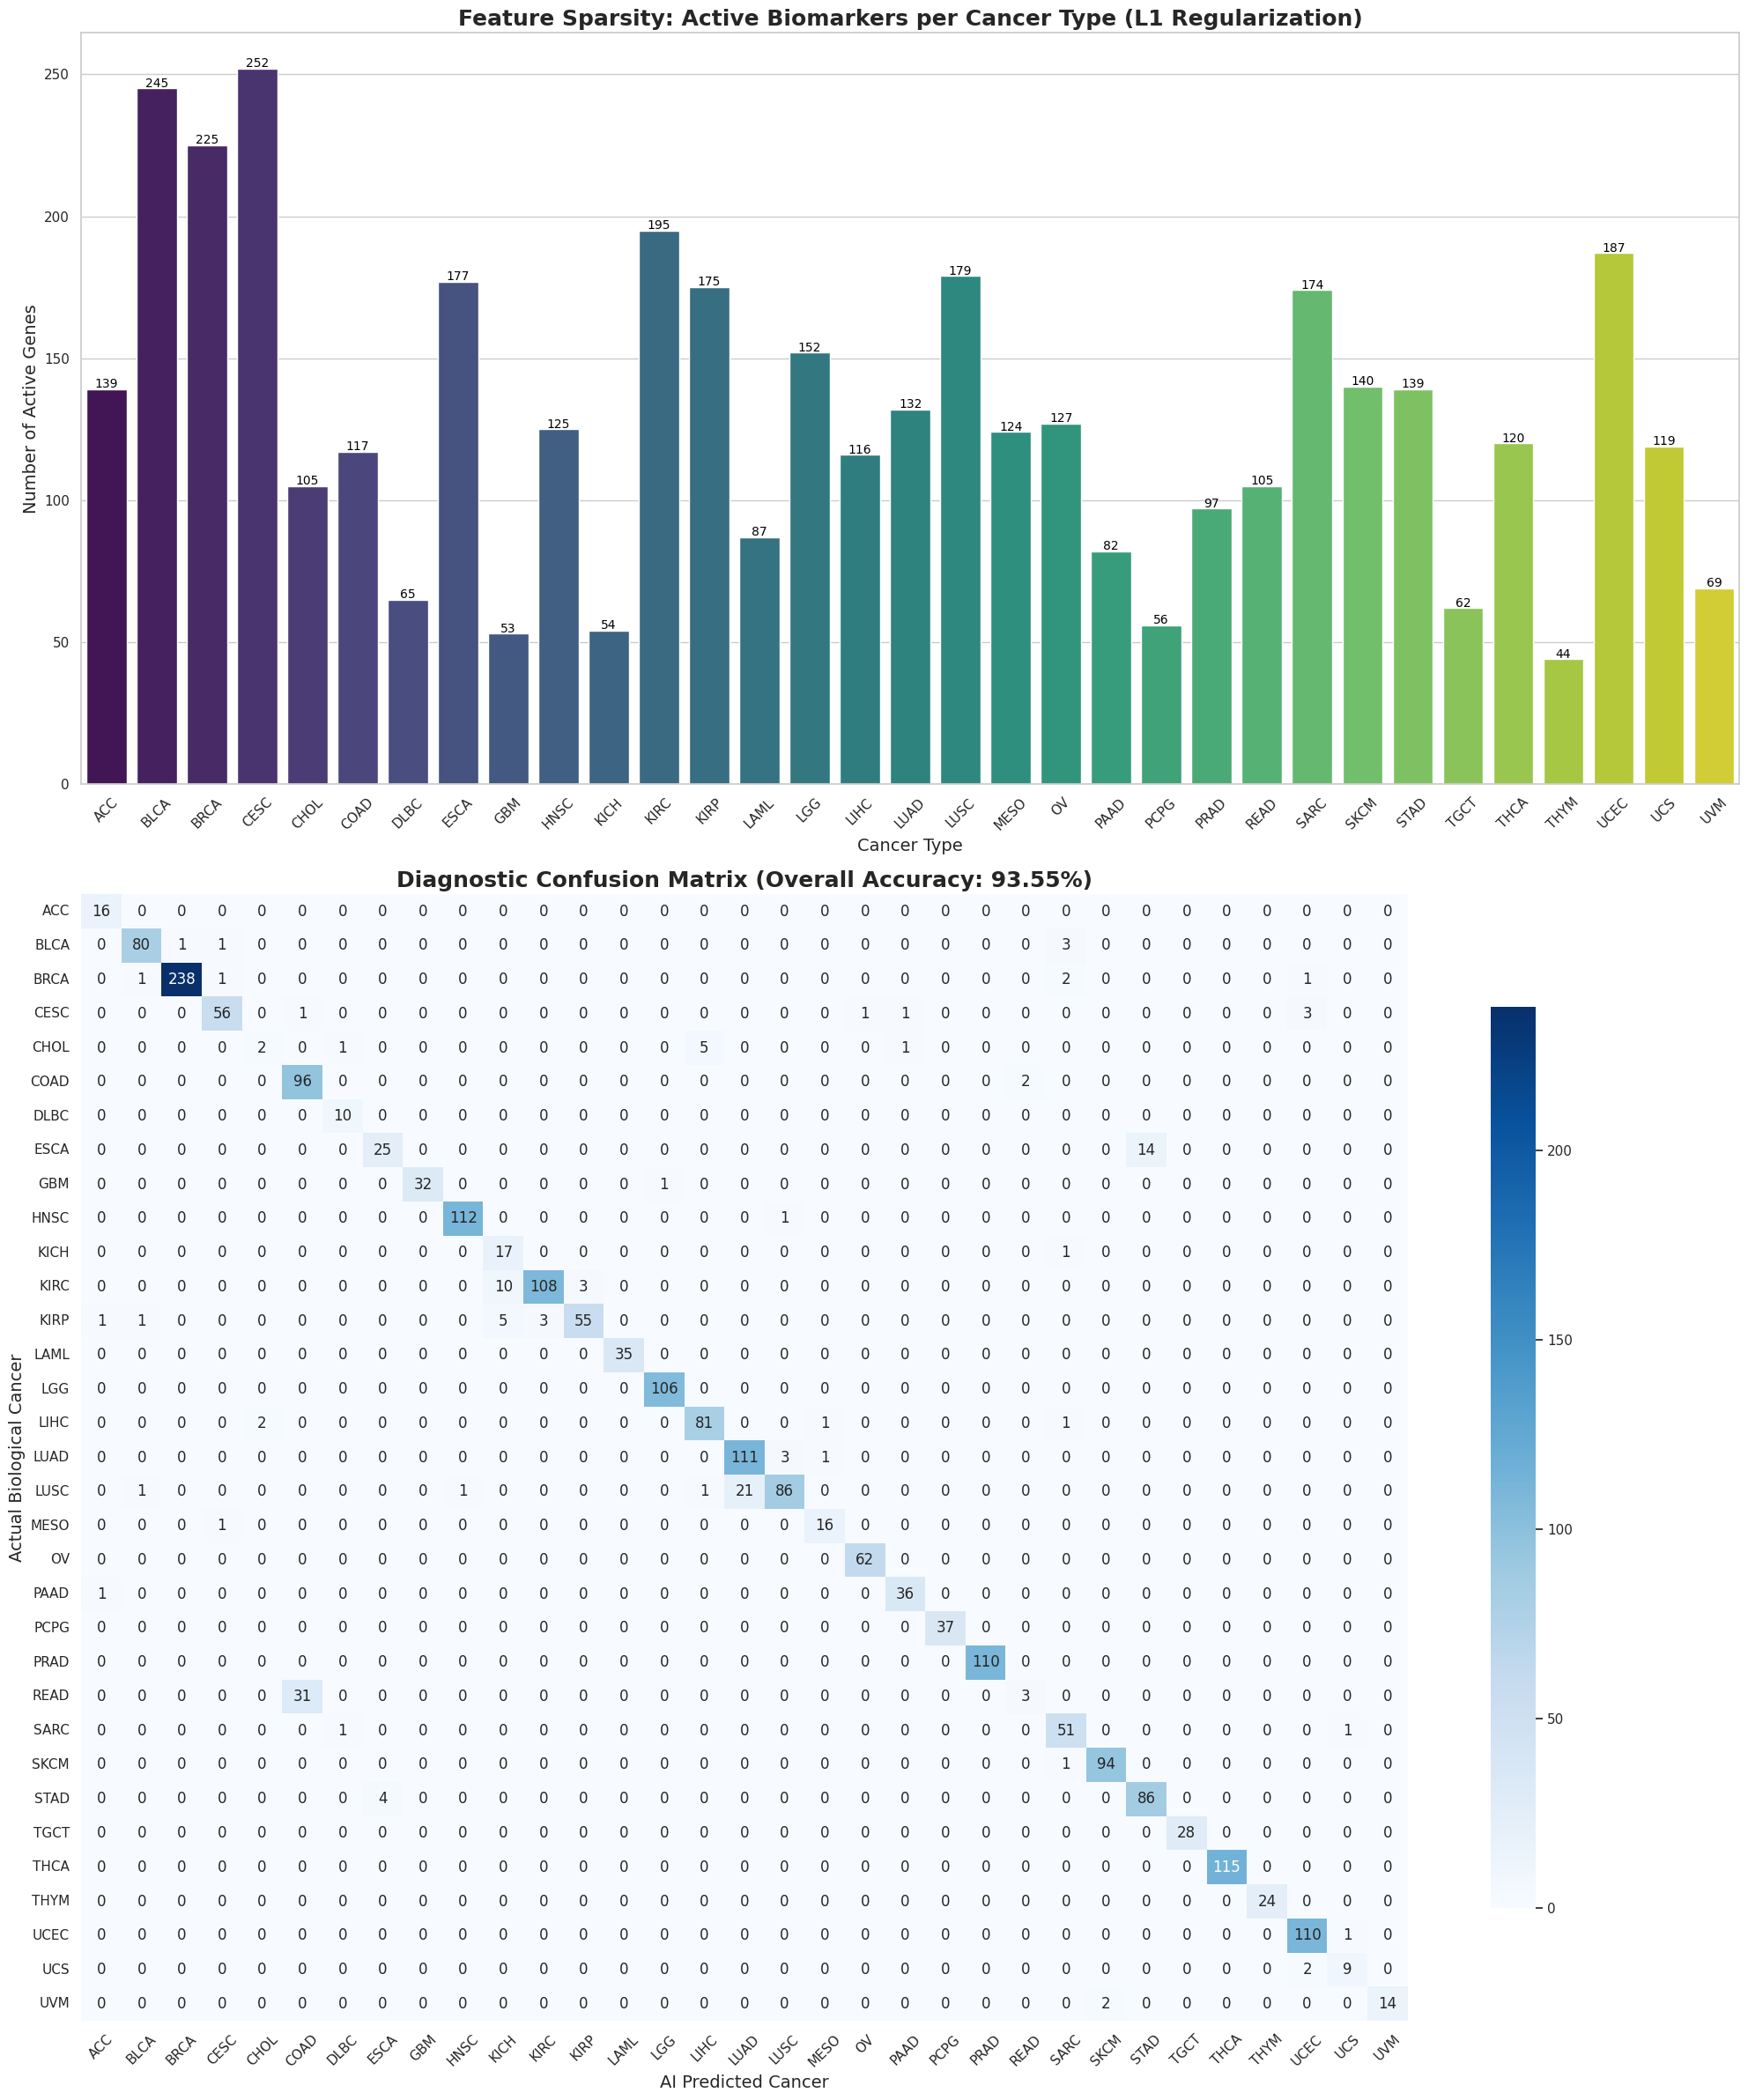

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(20, 24), gridspec_kw={'height_ratios': [1, 1.5]})

# ==========================================
# CHART 1: The "Lasso Sparsity" Bar Chart
# ==========================================
active_genes_per_cancer = np.sum(weights != 0, axis=1)

sns.barplot(
    x=classes,
    y=active_genes_per_cancer,
    hue=classes,
    legend=False,
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Feature Sparsity: Active Biomarkers per Cancer Type (L1 Regularization)", fontsize=18, fontweight='bold')
axes[0].set_ylabel("Number of Active Genes", fontsize=14)
axes[0].set_xlabel("Cancer Type", fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Add the exact number on top of each bar
for i, v in enumerate(active_genes_per_cancer):
    axes[0].text(i, v + 0.5, str(v), color='black', ha='center', fontsize=10)

# ==========================================
# CHART 2: The 33-Class Confusion Matrix
# ==========================================
cm = confusion_matrix(y_test, y_pred, labels=classes)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[1],
    cbar_kws={'shrink': 0.8}
)
axes[1].set_title(f"Diagnostic Confusion Matrix (Overall Accuracy: {acc*100:.2f}%)", fontsize=18, fontweight='bold')
axes[1].set_ylabel("Actual Biological Cancer", fontsize=14)
axes[1].set_xlabel("AI Predicted Cancer", fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(folder_path + 'Capstone_33_Cancer_Charts.png', dpi=300, bbox_inches='tight')

plt.show()